In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import os
from PIL import Image
from sklearn.metrics import f1_score


#Exploring the hyperspectral
## Download the Berlin dataset to your folder

### Load the HSI data

In [6]:

# Define the folder path and file name
folder_path = 'HS-SAR_Berlin'

os.chdir(folder_path)

# Load the .mat file
mat_data = scipy.io.loadmat('data_HS_LR.mat')
print(mat_data.keys())
HSI_data = mat_data['data_HS_LR']

dict_keys(['__header__', '__version__', '__globals__', 'data_HS_LR'])


In [7]:
HSI_data= HSI_data.astype(np.float32)

In [4]:
HSI_data.dtype

dtype('float32')

# load the SAR data

In [5]:
SAR_data = scipy.io.loadmat('data_SAR_HR.mat')

In [6]:
print(SAR_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data_SAR_HR'])


In [8]:
sar_data= SAR_data['data_SAR_HR']

In [9]:
sar_data.shape

(1723, 476, 4)

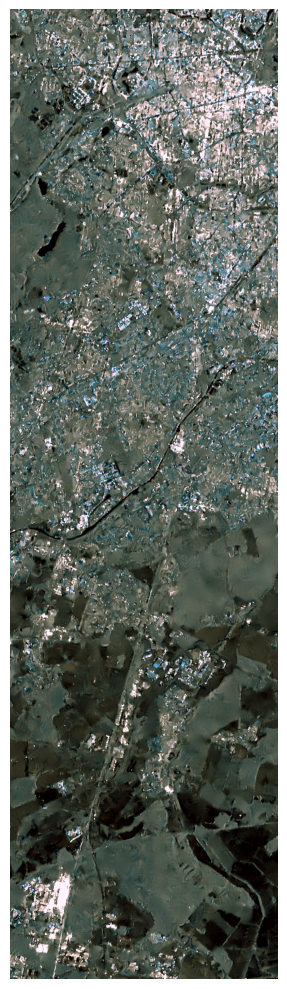

In [31]:
def normalize_for_visualization(band, clip_low=5, clip_high=98):
    clip_min = np.percentile(band, clip_low)
    clip_max = np.percentile(band, clip_high)
    band = np.clip(band, clip_min, clip_max)
    band = np.sqrt(band)  # or np.log1p(band)
    band = (band - band.min()) / (band.max() - band.min() + 1e-8)
    return band

def pauli_rgb_improved(sar_data):
    C11 = sar_data[:, :, 0]
    C22 = sar_data[:, :, 1]
    R = np.abs(C11 - C22)
    G = 2 * np.sqrt(np.abs(C22))
    B = np.abs(C11 + C22)

    Rn = normalize_for_visualization(R, 2, 98)
    Gn = normalize_for_visualization(G, 2, 98)
    Bn = normalize_for_visualization(B, 2, 98)

    Rn *= 1.25
    Gn *= 0.95
    Bn *= 1.15
    


    rgb_image = np.stack([Rn, Gn, Bn], axis=-1)
    rgb_image = np.clip(rgb_image, 0, 1)

    # Optional: Gamma correction
    gamma = 0.8
    rgb_image = rgb_image ** gamma

    plt.figure(figsize=(6, 10))
    plt.imshow(rgb_image)
    # plt.title("Pauli-like RGB (Improved Contrast)")  # Optional
    plt.axis("off")
    plt.tight_layout()
    
    plt.savefig("pauli_sar_publication.png", dpi=300, bbox_inches='tight', pad_inches=0)
    # Show for interactive inspection (optional)
    plt.show()

    return rgb_image
pauli_rgb = pauli_rgb_improved(sar_data)


In [10]:
# Load the .mat file
mat_data = scipy.io.loadmat('TrainImage.mat')
#print out the varialbe of .mat data
print(mat_data.keys())
train_label= mat_data['TrainImage']

dict_keys(['__header__', '__version__', '__globals__', 'TrainImage'])


In [11]:
train_label.dtype

dtype('uint8')

In [14]:
train_label.shape

(1723, 476)

In [12]:
# Load the .mat file
mat_data = scipy.io.loadmat('TestImage.mat')
#print out the varialbe of .mat data
print(mat_data.keys())
test_label = mat_data['TestImage']

dict_keys(['__header__', '__version__', '__globals__', 'TestImage'])


## HSI data has 244 bands with spatial size 1723by476

In [11]:
HSI_data.shape

(1723, 476, 244)

check unique elements

## Set color palette for segmentation

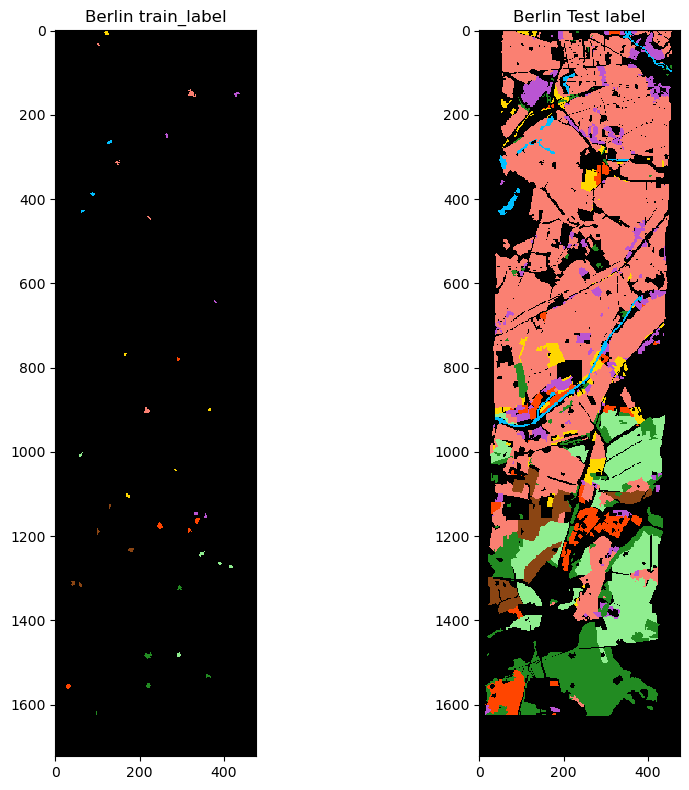

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


palette = [
    (0, 0, 0),         # Black for background
    (34, 139, 34),     # Dark Green for Forest (#228B22)
    (250, 128, 114),   # Salmon for Residential Area (#FA8072)
    (255, 69, 0),      # OrangeRed for Industrial Area (#FF4500)
    (144, 238, 144),   # Light Green for Low Plants (#90EE90)
    (139, 69, 19),     # Saddle Brown for Soil (#8B4513)
    (255, 215, 0),     # Yellow for Allotment (#FFD700)
    (186, 85, 211),    # Medium Orchid for Commercial Area (#BA55D3)
    (0, 191, 255)      # Deep Sky Blue for Water (#00BFFF)
]


# Normalize the RGB values to be between 0 and 1
custom_palette = [(r / 255.0, g / 255.0, b / 255.0) for r, g, b in palette]

# Create the colormap using the artistic colors
cmap  = mcolors.ListedColormap(custom_palette)


# plot the train label and test label with color palette
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))

# Plot data on each subplot
# First subplot
axs[0].imshow(train_label, cmap = cmap, interpolation='nearest')
axs[0].set_title('Berlin train_label')

# Second subplot
axs[1].imshow(test_label,cmap = cmap,interpolation='nearest' )  # Example plot data
axs[1].set_title('Berlin Test label')

plt.tight_layout()
plt.show()

## Visualize the legend

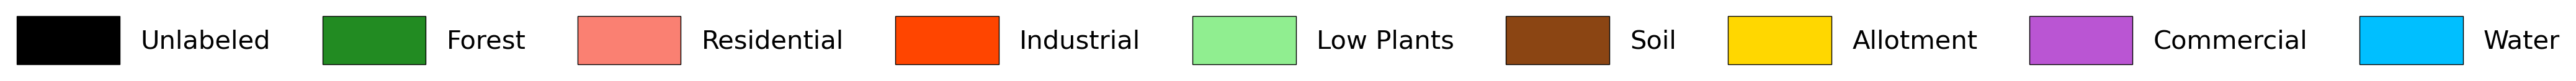

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Define the colors and labels for the legend
legend_elements = [
    Patch(facecolor='#000000', edgecolor='black', label='Unlabeled'),  # Black for background
    Patch(facecolor='#228B22', edgecolor='black', label='Forest'),      # Dark Green for Forest
    Patch(facecolor='#FA8072', edgecolor='black', label='Residential'),  # Salmon for Residential Area
    Patch(facecolor='#FF4500', edgecolor='black', label='Industrial'),   # OrangeRed for Industrial Area
    Patch(facecolor='#90EE90', edgecolor='black', label='Low Plants'),        # Light Green for Low Plants
    Patch(facecolor='#8B4513', edgecolor='black', label='Soil'),              # Saddle Brown for Soil
    Patch(facecolor='#FFD700', edgecolor='black', label='Allotment'),         # Yellow for Allotment
    Patch(facecolor='#BA55D3', edgecolor='black', label='Commercial'),   # Medium Orchid for Commercial Area
    Patch(facecolor='#00BFFF', edgecolor='black', label='Water')              # Deep Sky Blue for Water
]

fig, ax = plt.subplots(figsize=(10, 0.5))

ax.legend(handles=legend_elements, loc='center', fontsize=30, frameon=False, ncol=len(legend_elements),handleheight=2.5, handlelength=4, bbox_to_anchor=(0.5, -0.1), bbox_transform=fig.transFigure)

# Remove the axes
ax.axis('off')
# Remove the border
plt.gca().set_frame_on(False)

# Save the legend as an image
plt.savefig('legend_horizontal_7_15.pdf', format='pdf', bbox_inches='tight')
# Display the plot
plt.show()

## Show RGB color image ,assuming Red the 40 channel, Green is the 30 th channel, and Blue is the 15th channel

600nm rband 34th , 550 16th nm green band, 450 blue bands 5th, try th combination of

# stretch min max rgb visalization

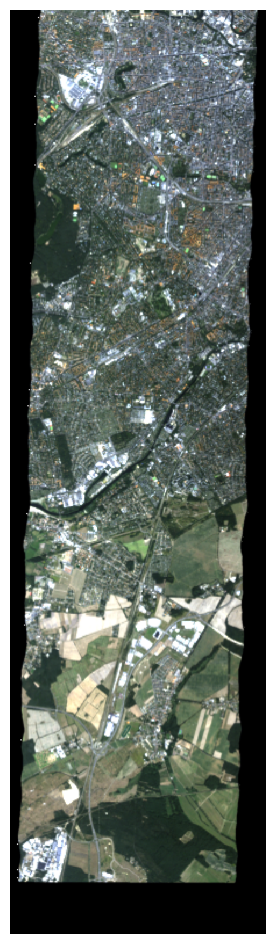

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Extract bands
red = HSI_data[:, :, 40]
green = HSI_data[:, :, 30]
blue = HSI_data[:, :, 15]
rgb_image = np.stack((red, green, blue), axis=-1)

# Percentile-based contrast stretching
def percentile_stretch(img, lower=2, upper=98):
    stretched = np.zeros_like(img, dtype=np.float32)
    for i in range(3):
        band = img[:, :, i]
        low_val = np.percentile(band, lower)
        high_val = np.percentile(band, upper)
        stretched[:, :, i] = np.clip((band - low_val) / (high_val - low_val + 1e-6), 0, 1)
    return stretched

# Apply 2–98% stretch
stretched_rgb = percentile_stretch(rgb_image)

# Convert to 8-bit for saving
rgb_8bit = (stretched_rgb * 255).astype(np.uint8)

# Save using PIL for raw image (optional)
Image.fromarray(rgb_8bit).save("RGB_percentile_stretch_8bit.png")

# Create publication-ready plot with scalebar and label
fig, ax = plt.subplots(figsize=(8, 12))  # Adjust size as needed
ax.imshow(rgb_8bit)
ax.axis("off")


# Save figure for publication (300 DPI)
#plt.savefig("RGB_publication_ready.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


In [ ]:
rgb_patch_normalized_pil = (gamma_corrected * 255).astype(np.uint8)  # Scale to 0-255

img = Image.fromarray(rgb_patch_normalized_pil)

# visualize  PCA as rgb 

PCA Variance Ratio: [0.67305883 0.28769705 0.02413722]


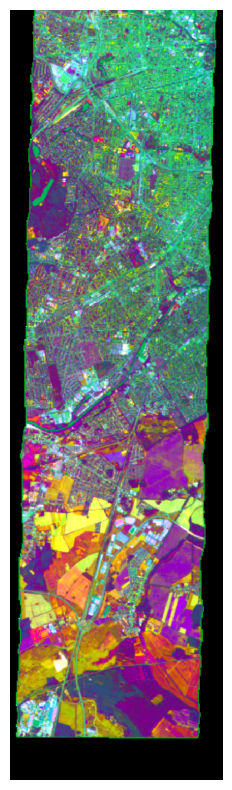

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def stretch_minmax(image, lower_percentile=2, upper_percentile=98):
    """Apply Min-Max Stretching with percentile capping to remove outliers."""
    lower = np.percentile(image, lower_percentile)  # Get lower bound (2%)
    upper = np.percentile(image, upper_percentile)  # Get upper bound (98%)
    stretched = np.clip(image, lower, upper)  # Clip extreme values
    return (stretched - lower) / (upper - lower)  # Normalize to 0-1


h, w, bands = HSI_data.shape
HSI_reshaped = HSI_data.reshape(-1, bands)

mask_non_zero = np.any(HSI_reshaped != 0, axis=1)  # Identify non-zero pixels
HSI_non_zero = HSI_reshaped[mask_non_zero]  # Keep only non-zero values


pca = PCA(n_components=3)
HSI_pca = pca.fit_transform(HSI_non_zero)

explained_variance = pca.explained_variance_ratio_
print(f"PCA Variance Ratio: {explained_variance}")

HSI_pca_stretched = np.zeros_like(HSI_pca)
for i in range(3):  # Apply separately to each channel
    HSI_pca_stretched[:, i] = stretch_minmax(HSI_pca[:, i])


HSI_pca_rgb = np.zeros((h * w, 3))  # Initialize with black (zero)
HSI_pca_rgb[mask_non_zero] = HSI_pca_stretched  # Assign PCA-transformed values
HSI_pca_rgb_image = HSI_pca_rgb.reshape(h, w, 3)  # Reshape back to image

HSI_pca_rgb_final = np.zeros_like(HSI_pca_rgb_image)  # Initialize with black background
for i in range(3):
    non_zero_pixels = HSI_pca_rgb_image[:, :, i][mask_non_zero.reshape(h, w)]
    HSI_pca_rgb_final[:, :, i][mask_non_zero.reshape(h, w)] = stretch_minmax(non_zero_pixels)

plt.figure(figsize=(10, 10))
plt.imshow(HSI_pca_rgb_final)
plt.axis('off')  # Remove axes
#plt.savefig("PCA_publication_ready.png", dpi=300, bbox_inches='tight', pad_inches=0)

plt.show()


# plot training and test data pixel distribution

In [ ]:
from PIL import Image


# Convert from 0-1 to 0-255
pca_rgb_8bit = (HSI_pca_rgb_final * 255).astype(np.uint8)

# Save as image
img = Image.fromarray(pca_rgb_8bit)
img.save("pca_rgb_image.png")


In [ ]:
import os
import shutil
import glob

def move_npz_files(source_folder, destination_folder):
    """
    Moves all .npz files from source_folder to destination_folder.

    Parameters:
        source_folder (str): Path to the folder containing .npz files.
        destination_folder (str): Path to the folder where .npz files will be moved.
    """

    # Ensure the destination folder exists
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    # Find all .npz files in the source folder
    npz_files = glob.glob(os.path.join(source_folder, "*.npy"))

    if not npz_files:
        print("No .npz files found in the source folder.")
        return

    for file in npz_files:
        try:
            shutil.move(file, destination_folder)
            print(f"Moved: {file} -> {destination_folder}")
        except Exception as e:
            print(f"Error moving {file}: {e}")

# Example usage
source_folder = "Berlin_benchmark_test_pca_32"  # Replace with your actual source folder
destination_folder = "Berlin_benchmark_test_pca_patch"  # Replace with your actual destination folder

move_npz_files(source_folder, destination_folder)


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from PIL import Image

def apply_pca_rgb(HSI_patch, n_components=3):
    """Applies PCA to a hyperspectral patch and converts it into a normalized RGB image. Also returns preserved variance."""
    
    def stretch_minmax(image, lower_percentile=2, upper_percentile=98):
        """Apply Min-Max Stretching with percentile capping to remove outliers."""
        lower = np.percentile(image, lower_percentile)
        upper = np.percentile(image, upper_percentile)
        stretched = np.clip(image, lower, upper)
        return (stretched - lower) / (upper - lower) if upper > lower else np.zeros_like(image)
    
    # **Fix: Transpose shape from (Bands, H, W) → (H, W, Bands)**
    if HSI_patch.shape[0] > HSI_patch.shape[-1]:  
        HSI_patch = np.transpose(HSI_patch, (1, 2, 0))  # Change to (H, W, Bands)

    h, w, bands = HSI_patch.shape
    HSI_reshaped = HSI_patch.reshape(-1, bands)

    # Identify non-zero pixels
    mask_non_zero = np.any(HSI_reshaped != 0, axis=1)
    HSI_non_zero = HSI_reshaped[mask_non_zero]

    if HSI_non_zero.shape[0] == 0:
        return np.zeros((h, w, 3)), 0  # Return a black image with 0 variance if no valid pixels exist

    # Apply PCA
    pca = PCA(n_components=n_components)
    HSI_pca = pca.fit_transform(HSI_non_zero)

    # Get explained variance ratio (how much variance is preserved)
    explained_variance_ratio = np.sum(pca.explained_variance_ratio_)
    print(f"Preserved Variance for patch: {explained_variance_ratio:.4f}")

    # Normalize each PCA channel separately
    HSI_pca_stretched = np.zeros_like(HSI_pca)
    for i in range(n_components):
        HSI_pca_stretched[:, i] = stretch_minmax(HSI_pca[:, i])

    # Reconstruct full image
    HSI_pca_rgb = np.zeros((h * w, 3))  
    HSI_pca_rgb[mask_non_zero] = HSI_pca_stretched  
    HSI_pca_rgb_image = HSI_pca_rgb.reshape(h, w, 3)  

    # Final normalization for better contrast
    HSI_pca_rgb_final = np.zeros_like(HSI_pca_rgb_image)
    for i in range(3):
        non_zero_pixels = HSI_pca_rgb_image[:, :, i][mask_non_zero.reshape(h, w)]
        HSI_pca_rgb_final[:, :, i][mask_non_zero.reshape(h, w)] = stretch_minmax(non_zero_pixels)

    return (HSI_pca_rgb_final * 255).astype(np.uint8), explained_variance_ratio  # Convert to 8-bit RGB format

def process_hyperspectral_patches(source_folder, destination_folder):
    """Processes all .npz files in the source folder, applies PCA, and saves them as PNG images. Also prints variance preserved."""

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    npz_files = glob.glob(os.path.join(source_folder, "*.npz"))

    if not npz_files:
        print("No .npz files found in the source folder.")
        return

    total_variance = []
    
    for file in npz_files:
        try:
            # Load hyperspectral data with key checking
            data = np.load(file)
            keys = list(data.keys())  # List all keys in the file

            if not keys:
                print(f"Skipping {file} - No data found.")
                continue

            # Print available keys for debugging
            print(f"Processing {file} - Keys found: {keys}")

            # Attempt to extract the first key (if keys vary)
            HSI_patch = data[keys[0]]  # Use the first available key

            if len(HSI_patch.shape) != 3:
                print(f"Skipping {file} - Invalid shape: {HSI_patch.shape}")
                continue

            # Apply PCA and convert to RGB
            rgb_patch, variance_preserved = apply_pca_rgb(HSI_patch)
            total_variance.append(variance_preserved)

            # Save as PNG
            filename = os.path.splitext(os.path.basename(file))[0] + ".png"
            save_path = os.path.join(destination_folder, filename)

            Image.fromarray(rgb_patch).save(save_path)
            print(f"Saved: {save_path} | Variance Preserved: {variance_preserved:.4f}")

        except Exception as e:
            print(f"Error processing {file}: {e}")

    # Print overall variance stats
    if total_variance:
        avg_variance = np.mean(total_variance)
        print(f"\nAverage Variance Preserved across all patches: {avg_variance:.4f}")

# Example usage
source_folder = "Berlin_benchmark_test_pca_patch"  # Replace with your actual source folder
destination_folder = "Berlin_benchmark_test_pca_patch_output"  # Replace with your actual destination folder

process_hyperspectral_patches(source_folder, destination_folder)


# Divide hyperspectal image cubes  and its label with overlapping

## create folder Berlin_benchmark_train_data_32
## train data is stored under this folder

In [ ]:

current_dir = os.getcwd()
print(current_dir)
folder_name = 'Berlin_benchmark_train_rgb_32'
# Construct the path
Berlin_64_train_data_32= os.path.join(current_dir, folder_name)
os.makedirs(Berlin_64_train_data_32, exist_ok=True)
print(Berlin_64_train_data_32) #save divided hyperspectral cube data and rgb patches into traiinng folder

## create train data with pca as rgb

In [ ]:

current_dir = os.getcwd()
print(current_dir)
folder_name = 'Berlin_benchmark_train_pca_32'
# Construct the path
Berlin_64_train_pca_32= os.path.join(current_dir, folder_name)
os.makedirs(Berlin_64_train_pca_32, exist_ok=True)
print(Berlin_64_train_pca_32) #save divided hyperspectral cube data and rgb patches into traiinng folder

# create train data with strethed rgb 

In [42]:

current_dir = os.getcwd()
print(current_dir)
folder_name = 'Berlin_benchmark_train_rgb_32'
# Construct the path
Berlin_64_train_rgb_32= os.path.join(current_dir, folder_name)
os.makedirs(Berlin_64_train_rgb_32, exist_ok=True)
print(Berlin_64_train_rgb_32) #save divided hyperspectral cube data and rgb patches into traiinng folder

E:\unidiff\HS-SAR_Berlin
E:\unidiff\HS-SAR_Berlin\Berlin_benchmark_train_rgb_32


## create train data with pca 

In [59]:

current_dir = os.getcwd()
print(current_dir)
folder_name = 'Berlin_benchmark_train_pca_32'
# Construct the path
Berlin_64_train_pca_32= os.path.join(current_dir, folder_name)
os.makedirs(Berlin_64_train_pca_32, exist_ok=True)
print(Berlin_64_train_pca_32) #save divided hyperspectral cube data and rgb patches into traiinng folder

E:\unidiff\HS-SAR_Berlin
E:\unidiff\HS-SAR_Berlin\Berlin_benchmark_train_pca_32


## Create train data with SAR

In [27]:

current_dir = os.getcwd()
print(current_dir)
folder_name = 'Berlin_benchmark_train_SAR_32'
# Construct the path
Berlin_64_train_sar_32= os.path.join(current_dir, folder_name)
os.makedirs(Berlin_64_train_sar_32, exist_ok=True)
print(Berlin_64_train_sar_32) #save divided hyperspectral cube data and rgb patches into traiinng folder

E:\unidiff\HS-SAR_Berlin
E:\unidiff\HS-SAR_Berlin\Berlin_benchmark_test_SAR_32


## create foder Berlin_benchmark_test_data_32
## test data patches is stored under this folder

In [57]:
current_dir = os.getcwd()
print(current_dir)

folder_name = 'Berlin_benchmark_test_rgb_32'
# Construct the path
Berlin_64_test_rgb_32 = os.path.join(current_dir, folder_name)
os.makedirs(Berlin_64_test_rgb_32, exist_ok=True)
print(Berlin_64_test_pca_32) #save divided patches into folder "hyperspectral_traninning_64"

E:\unidiff\HS-SAR_Berlin
E:\unidiff\HS-SAR_Berlin\Berlin_benchmark_test_rgb_32


In [60]:
current_dir = os.getcwd()
print(current_dir)

folder_name = 'Berlin_benchmark_test_pca_32'
# Construct the path
Berlin_64_test_pca_32 = os.path.join(current_dir, folder_name)
os.makedirs(Berlin_64_test_pca_32, exist_ok=True)
print(Berlin_64_test_pca_32) #save divided patches into folder "hyperspectral_traninning_64"

E:\unidiff\HS-SAR_Berlin
E:\unidiff\HS-SAR_Berlin\Berlin_benchmark_test_pca_32


In [ ]:

current_dir = os.getcwd()
print(current_dir)
folder_name = 'Berlin_benchmark_test_SAR_32'
# Construct the path
Berlin_64_test_sar_32= os.path.join(current_dir, folder_name)
os.makedirs(Berlin_64_test_sar_32, exist_ok=True)
print(Berlin_64_test_sar_32) #save divided hyperspectral cube data and rgb patches into traiinng folder

# divide Berlin hyperspectral big rgb image into 64by64 patches with overlapping 32
original width: 476 ,
original height : 1723,
adjusted width :480 ,
adjusted height : 1728,

*alltother divided into 742 patches*

In [23]:
import pdb
def divide_into_patches_with_reflect_padding(image, label, train_data_244,output_folder ,patch_size=64, overlap=32):

    stride = patch_size - overlap
    original_width, original_height = image.size
    # Calculate necessary padding to fit stride

    adjusted_width =((original_width - patch_size) // stride + 1) * stride + patch_size
    adjusted_height = ((original_height - patch_size) // stride + 1) * stride + patch_size

    print(f"original_width : {original_width}, original height: {original_height}")
    print(f"adjusted_width: {adjusted_width} , adjusted_height: {adjusted_height}")

    padded_horizontal = adjusted_width- original_width
    padded_vertical= adjusted_height- original_height

    padded_image = Image.new("RGB", (adjusted_width, adjusted_height), (0, 0, 0))

    # Paste the original image onto the padded image with the desired offset
    padded_image.paste(image, (padded_horizontal, padded_vertical))
    padded_image = np.array(padded_image)

    padded_label = np.pad(label, ((padded_vertical, 0), (padded_horizontal, 0)),mode='constant', constant_values=0)

    #setting pad_width for train_data cube data
    pad_width = ((0, 0),  # No padding for the first dimension
             (padded_vertical,0),  # Add 3 rows at the end of the second dimension
             (padded_horizontal, 0)) # Add 15 columns at the end of the third dimension

    padded_train_data= np.pad(train_data_244,pad_width,mode='constant', constant_values=0)


    patch_number = 0

    # Generate patches
    for i in range(0, padded_image.shape[0] - patch_size + 1, stride):
        for j in range(0, padded_image.shape[1] - patch_size + 1, stride):
            patch_img = padded_image[i:i + patch_size, j:j + patch_size]
            patch_label = padded_label[i:i + patch_size, j:j + patch_size]
            patch_train_data = padded_train_data[:,i:i + patch_size, j:j + patch_size]

            # Format the filename with leading zeros and a unique patch number 
            filename_img = f"{output_folder}/hyperspectral{patch_number}.png"
            filename_label = f"{output_folder}/hyperspectral{patch_number}.npy"
            filename_train_data = f"{output_folder}/hyperspectral{patch_number}.npz"

            patch_img = Image.fromarray(patch_img)
            patch_img.save(filename_img)
            np.save(filename_label,patch_label)
            np.savez(filename_train_data,arr1= patch_train_data)
            patch_number += 1

    return patch_number



**pay attention** In the UH dataset, the first dimension is band channels while in Berlin dataset the third dimension is band channels

In [24]:
hsi_data = HSI_data.transpose(2,0,1) # swith channels

In [25]:
hsi_data.shape

(244, 1723, 476)

## divide for train set and test set

save train data to Berlin_64_train_data_32

## read from sar image

In [ ]:
pauli_rgb

In [34]:

sar_rgb_8bit = (pauli_rgb * 255).astype(np.uint8)

# Save image using PIL
img = Image.fromarray(sar_rgb_8bit)


## read from psedo rgb as rgb_8bit

In [48]:
img = Image.fromarray(rgb_8bit)


In [35]:
Berlin_64_train_sar_32

'E:\\unidiff\\HS-SAR_Berlin\\Berlin_benchmark_train_SAR_32'

## read from pca image

In [56]:
pca_rgb_8bit = (HSI_pca_rgb_final * 255).astype(np.uint8)

# Save image using PIL
img = Image.fromarray(pca_rgb_8bit)


In [56]:
train_label.shape

(1723, 476)

In [57]:
img = Image.fromarray(rgb_8bit)


In [49]:
patches_num = divide_into_patches_with_reflect_padding(img,train_label,hsi_data, Berlin_64_train_rgb_32, 64, 32)

print("Number of patches:", patches_num)

original_width : 476, original height: 1723
adjusted_width: 480 , adjusted_height: 1728
Number of patches: 742


In [61]:
patches_num = divide_into_patches_with_reflect_padding(img,train_label,hsi_data, Berlin_64_train_pca_32, 64, 32)
print("Number of patches:", patches_num)
print("Number of patches:", patches_num)

original_width : 476, original height: 1723
adjusted_width: 480 , adjusted_height: 1728
Number of patches: 742
Number of patches: 742


In [36]:
patches_num = divide_into_patches_with_reflect_padding(img,train_label,hsi_data, Berlin_64_train_sar_32, 64, 32)
print("Number of patches:", patches_num)
print("Number of patches:", patches_num)

original_width : 476, original height: 1723
adjusted_width: 480 , adjusted_height: 1728
Number of patches: 742
Number of patches: 742


In [50]:
patches_num = divide_into_patches_with_reflect_padding(img,test_label,hsi_data, Berlin_64_test_rgb_32, 64, 32)

print("Number of patches:", patches_num)

original_width : 476, original height: 1723
adjusted_width: 480 , adjusted_height: 1728
Number of patches: 742


In [62]:

patches_num = divide_into_patches_with_reflect_padding(img,test_label,hsi_data, Berlin_64_test_pca_32, 64, 32)

print("Number of patches:", patches_num)


original_width : 476, original height: 1723
adjusted_width: 480 , adjusted_height: 1728
Number of patches: 742


In [37]:
patches_num = divide_into_patches_with_reflect_padding(img,test_label,hsi_data, Berlin_64_test_sar_32, 64, 32)

print("Number of patches:", patches_num)

original_width : 476, original height: 1723
adjusted_width: 480 , adjusted_height: 1728
Number of patches: 742
